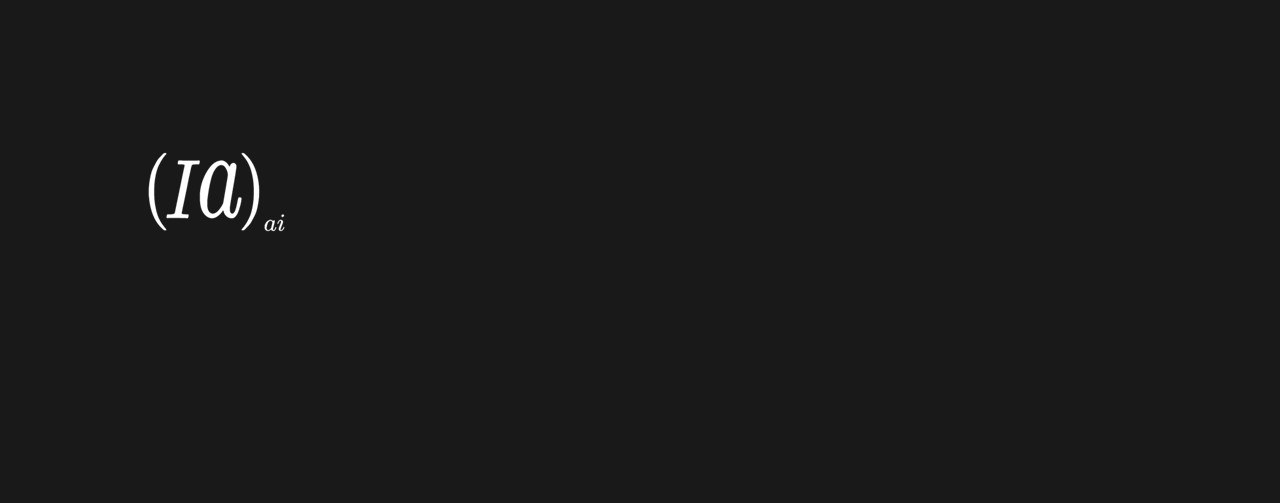

# Nanoeconomics Survival Simulation — Walkthrough

> **Intelligent Actuaries Research Lab.** This notebook is part of the open
> research output of the Intelligent Actuaries Research Lab. For questions,
> collaborations, or feedback, contact us at
> [research@intelligentactuaries.com](mailto:research@intelligentactuaries.com).

This notebook demonstrates the **risk-return tradeoff** in community wealth dynamics
under the $W(M, T, R)$ framework from Denewade (2025).

The core wealth function is **Cobb-Douglas**:

$$W(t) = M(t)^{\alpha_M} \cdot T(t)^{\alpha_T} \cdot R(t)^{\alpha_R}, \qquad \alpha_M + \alpha_T + \alpha_R = 1$$

where
- $M(t)$ — material / monetary capital
- $T(t)$ — productive time allocation
- $R(t)$ — relational capital (family, religious, spatial)

We will:
1. Run a **high-relational-capital** community and inspect its survival profile.
2. Compare it side-by-side with a **low-relational-capital** community.
3. Scale up to a **30-community society** with trade, migration, and contagion.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.community import CommunityConfig, TimeAllocation
from src.relational import RelationalConfig
from src.simulation import SingleCommunityConfig, run_single_community
from src.society import SocietyConfig
from src.animation import run_society_with_frames
from src.outcomes import Outcome

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)


## Single Community: Hazard and Survival

Each community faces a continuous-time hazard that depends on current wealth:

$$h(t) = h_0 \cdot \exp\!\left(-\beta_W \cdot \log\!\frac{W(t)}{W_0}\right)$$

Cumulative survival probability over horizon $T$:

$$S(T) = \exp\!\left(-\int_0^T h(t)\, dt\right) \;\approx\; \exp\!\left(-\sum_t h(t)\,\Delta t\right)$$

Outcomes are classified at simulation end:

| Outcome | Condition |
|---|---|
| **Collapsed**  | $W < \tau_c \cdot W_0$ for $\geq N_{\mathrm{rec}}$ consecutive periods |
| **Grew**       | $W(T) > W_0\,(1 + \tau_g)$ |
| **Stabilized** | $\lvert W(T) - W_0 \rvert / W_0 \leq \tau_s$ |
| **Declined**   | none of the above |


In [2]:
def make_single_cfg(sqft, family_t, religion_t, prod_t, n_paths=300):
    leisure_t = max(1 - prod_t - family_t - religion_t - 0.10, 0)
    return SingleCommunityConfig(
        community=CommunityConfig(
            population=500,
            sqft_per_resident=sqft,
            relational_config=RelationalConfig(w_family=0.4, w_religion=0.3, w_spatial=0.3),
            time_allocation=TimeAllocation(
                production=prod_t, family=family_t, religion=religion_t,
                spatial_maintenance=0.10, leisure=leisure_t,
            ),
        ),
        shock_environment='moderate',
        horizon=30, n_paths=n_paths, seed=42,
    )

high_r = run_single_community(
    make_single_cfg(sqft=200, family_t=0.30, religion_t=0.20, prod_t=0.35)
)
print(f'High-R: {high_r.n_paths} Monte Carlo paths over {high_r.config.horizon} years')
print('Outcome fractions:')
for o, f in sorted(high_r.outcome_fractions().items(), key=lambda x: -x[1]):
    print(f'  {o.value.capitalize():<11s} {f*100:5.1f}%')


High-R: 300 Monte Carlo paths over 30 years
Outcome fractions:
  Stabilized   55.7%
  Declined     35.7%
  Grew          8.7%
  Collapsed     0.0%


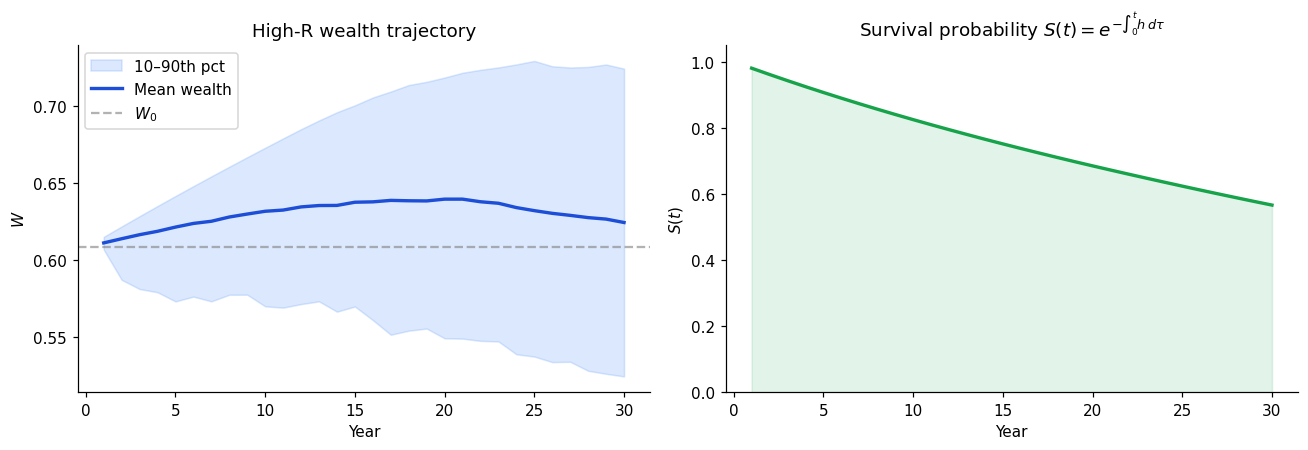

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

years = np.array(high_r.paths[0].years)
mean_w = np.array(high_r.mean_trajectory())
p10 = np.array(high_r.percentile_trajectory(10))
p90 = np.array(high_r.percentile_trajectory(90))

axes[0].fill_between(years, p10, p90, color='#3b82f6', alpha=0.18, label='10–90th pct')
axes[0].plot(years, mean_w, color='#1d4ed8', lw=2.2, label='Mean wealth')
axes[0].axhline(high_r.w0, ls='--', color='gray', alpha=0.6, label='$W_0$')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('$W$')
axes[0].set_title('High-R wealth trajectory'); axes[0].legend()

mean_s = np.array(high_r.mean_survival_curve())
axes[1].plot(years, mean_s, color='#16a34a', lw=2.2, label='Mean')
axes[1].fill_between(years, mean_s, 0, color='#16a34a', alpha=0.12)
axes[1].set_ylim(0, 1.05); axes[1].set_xlabel('Year'); axes[1].set_ylabel('$S(t)$')
axes[1].set_title('Survival probability $S(t) = e^{-\\int_0^t h\\,d\\tau}$')

plt.tight_layout(); plt.show()


## High-R vs. Low-R: The Tradeoff

Relational capital is composed as:

$$R(t) = w_F \cdot F(t) + w_{\mathrm{Rel}} \cdot \mathrm{Rel}(t) + w_S \cdot S(d), \qquad w_F + w_{\mathrm{Rel}} + w_S = 1$$

with each component on $[0, 1]$. We compare two configurations under the same shock seed:

- **High-R** — dense layout (200 sqft/resident), 30% family time, 20% religion time, 35% production.
- **Low-R**  — suburban (900 sqft/resident), 12% family, 5% religion, 50% production.

Decision-theory hypothesis: high-R sacrifices some upside (lower $\alpha_T \cdot t_{\mathrm{prod}}$)
in exchange for downside protection (higher $R$ → higher floor under shocks).


In [4]:
low_r = run_single_community(
    make_single_cfg(sqft=900, family_t=0.12, religion_t=0.05, prod_t=0.50)
)

def summarize(name, r):
    f = r.outcome_fractions()
    return {
        'Configuration':   name,
        'Grew':            f.get(Outcome.GREW, 0),
        'Stabilized':      f.get(Outcome.STABILIZED, 0),
        'Declined':        f.get(Outcome.DECLINED, 0),
        'Collapsed':       f.get(Outcome.COLLAPSED, 0),
        'Mean S(30)':      float(np.array(r.mean_survival_curve())[-1]),
        'Mean W(30) / W₀': float(np.array(r.mean_trajectory())[-1] / r.w0),
    }

comparison_df = pd.DataFrame([summarize('High-R', high_r), summarize('Low-R', low_r)])
comparison_df


,Configuration,Grew,Stabilized,Declined,Collapsed,Mean S(30),Mean W(30) / W₀
0,High-R,0.086667,0.556667,0.356667,0.0,0.566149,1.026627
1,Low-R,0.166667,0.483333,0.350000,0.0,0.574660,1.076981


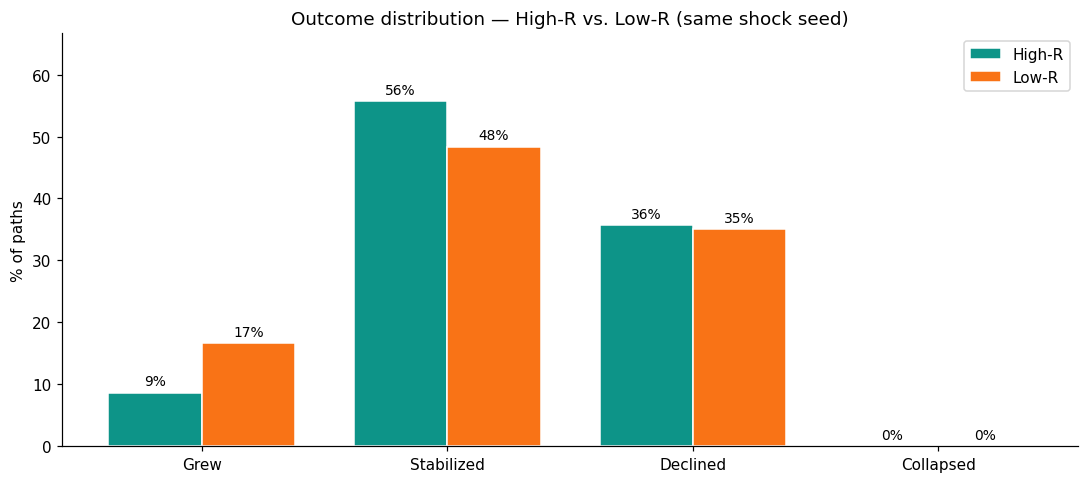

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
labels = ['Grew', 'Stabilized', 'Declined', 'Collapsed']
keys = [Outcome.GREW, Outcome.STABILIZED, Outcome.DECLINED, Outcome.COLLAPSED]

x = np.arange(len(labels)); w = 0.38
high_vals = [high_r.outcome_fractions().get(k, 0) * 100 for k in keys]
low_vals  = [low_r.outcome_fractions().get(k, 0) * 100 for k in keys]

ax.bar(x - w/2, high_vals, w, label='High-R', color='#0d9488', edgecolor='white')
ax.bar(x + w/2, low_vals,  w, label='Low-R',  color='#f97316', edgecolor='white')

for i, (h, l) in enumerate(zip(high_vals, low_vals)):
    ax.text(i - w/2, h + 1.2, f'{h:.0f}%', ha='center', fontsize=9)
    ax.text(i + w/2, l + 1.2, f'{l:.0f}%', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('% of paths')
ax.set_title('Outcome distribution — High-R vs. Low-R (same shock seed)')
ax.legend(loc='upper right')
ax.set_ylim(0, max(max(high_vals), max(low_vals)) * 1.18 + 1)
plt.tight_layout(); plt.show()


## Society Scale: Network Effects

A society of $N$ communities adds three coupling mechanisms.

**Trade — gravity model:**
$$\mathrm{Trade}_{ij}(t) = \kappa \cdot \frac{W_i(t)\, W_j(t)}{d_{ij}^2 + \varepsilon}$$

**R-contagion** — each community's relational capital is nudged toward its neighbors':
$$\Delta R_i^{\mathrm{contag}} = \alpha_c \cdot \big(\bar{R}_{\mathrm{nbrs},i} - R_i\big) \cdot \Delta t$$

**Migration** triggers when $W_i < \tau_m \cdot W_0^{(i)}$, redistributing $M$ from low-wealth
communities to higher-wealth neighbors with integration friction $f_{\mathrm{friction}}$.

Below: a **30-community mixed society** (25% each of four archetypes) over 30 years.


In [6]:
soc_cfg = SocietyConfig(
    n_communities=30,
    archetype_fractions={
        'strong_nuclear_religious_dense': 0.25,
        'independent_secular_suburban':   0.25,
        'extended_kin_religious_dense':   0.25,
        'mixed_diverse':                  0.25,
    },
    horizon=30, seed=42,
)
soc = run_society_with_frames(soc_cfg)

last = soc.frames[-1].metrics
print(f'Society at year {soc.config.horizon}: '
      f'total_wealth = {last.total_wealth:.2f}, Gini = {last.gini:.3f}')

society_df = pd.DataFrame({
    'Community':     [f'C{i:02d}' for i in range(len(soc.community_names))],
    'Archetype':     soc.community_names,
    'Final outcome': [o.value.capitalize() for o in soc.final_outcomes],
})
society_df.head(10)


Society at year 30: total_wealth = 9593.02, Gini = 0.047


,Community,Archetype,Final outcome
0,C00,Mixed/diverse,Grew
1,C01,Independent + secular + suburban,Grew
2,C02,Mixed/diverse,Grew
3,C03,Extended kin + religious + dense,Declined
4,C04,Strong nuclear + religious + dense,Declined
5,C05,Mixed/diverse,Grew
6,C06,Mixed/diverse,Grew
7,C07,Mixed/diverse,Grew
8,C08,Strong nuclear + religious + dense,Grew
9,C09,Independent + secular + suburban,Grew


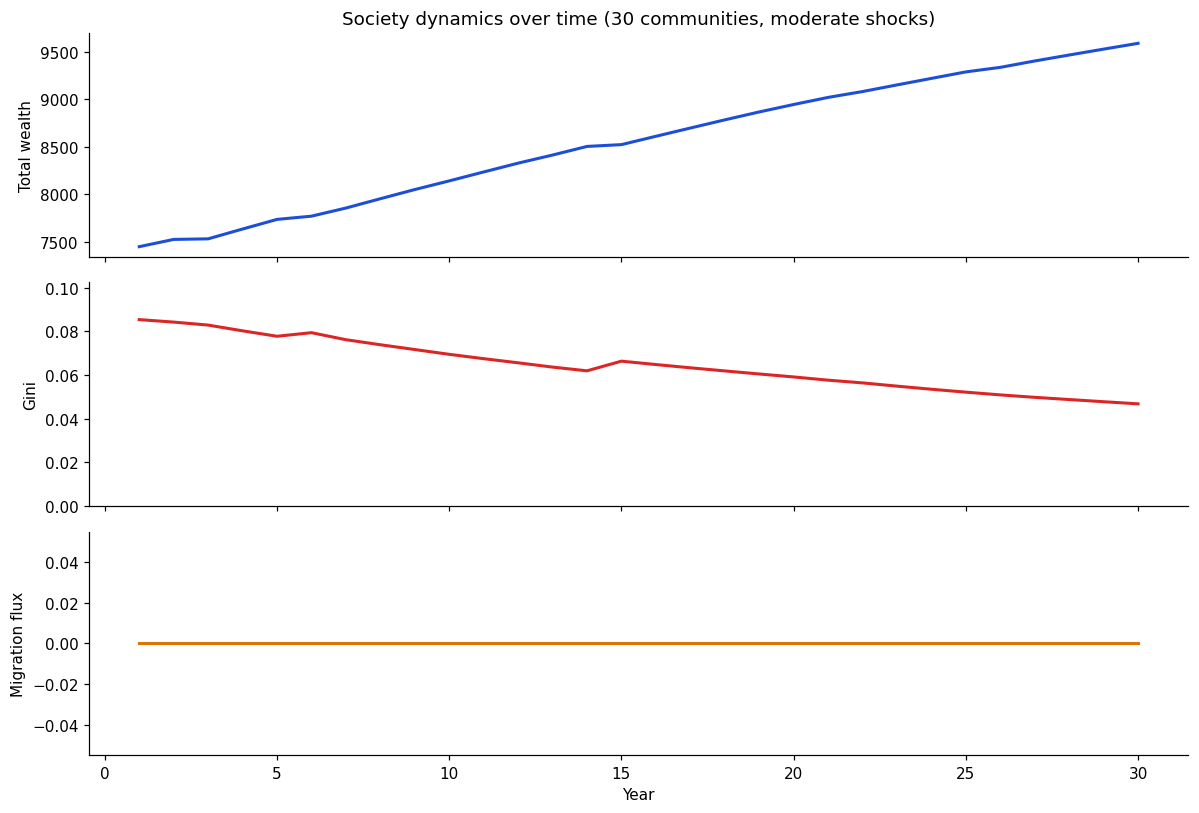

In [7]:
years    = [f.metrics.year for f in soc.frames]
total_w  = [f.metrics.total_wealth for f in soc.frames]
gini     = [f.metrics.gini for f in soc.frames]
mig      = [f.metrics.migration_flux for f in soc.frames]

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)

axes[0].plot(years, total_w, color='#1d4ed8', lw=2)
axes[0].set_ylabel('Total wealth')
axes[0].set_title('Society dynamics over time (30 communities, moderate shocks)')

axes[1].plot(years, gini, color='#dc2626', lw=2)
axes[1].set_ylabel('Gini')
axes[1].set_ylim(0, max(max(gini) * 1.2, 0.1))

axes[2].plot(years, mig, color='#d97706', lw=2)
axes[2].set_ylabel('Migration flux'); axes[2].set_xlabel('Year')

plt.tight_layout(); plt.show()


## Risk-Return Tradeoff: What the Math Showed

Across the three experiments above, the simulation produces a **risk-return tradeoff**
consistent with decision theory:

- **High-R** configurations show **lower collapse and decline** rates (downside protection)
  but **lower mean wealth growth** — because reducing $t_{\mathrm{prod}}$ (to invest in
  family / religion / spatial maintenance) directly reduces the $T$ term in
  $W = M^{\alpha_M} T^{\alpha_T} R^{\alpha_R}$.

- **Low-R** configurations show higher mean $W(T)$ but a **wider 10–90th percentile band**
  on the downside under stress — the math expression of higher variance.

- At the **society scale**, R-contagion and trade homogenize outcomes: inequality
  (Gini) tends to be lower in high-R-majority societies, but aggregate wealth is
  not mechanically higher — a network-level expression of the same tradeoff.

The simulation is **not a claim about real-world societies**. It explores the
implications of the $W(M, T, R)$ assumptions; whether real communities behave
this way under specific historical conditions is an empirical question requiring
real data, not simulation alone.

---

*Produced by the **Intelligent Actuaries Research Lab**. Questions, comments, or
research collaborations welcome at*
[research@intelligentactuaries.com](mailto:research@intelligentactuaries.com).
